# **Análise Exploratória dos Dados**
---

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Fase_01.csv')
df.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,2005-01-17,24.515,24.924,25.022,24.515,75060000.0,-1.64
1,2005-01-18,24.089,24.515,24.515,24.019,179420000.0,-1.74
2,2005-01-19,24.271,24.091,24.465,24.091,113110000.0,0.76
3,2005-01-20,23.610,24.271,24.271,23.534,182060000.0,-2.72
4,2005-01-21,23.818,23.618,24.006,23.609,97400000.0,0.88


In [4]:
# Converte a coluna 'DATA' para o tipo datetime
df['Data'] = pd.to_datetime(df['Data'])
# Ordenar o DataFrame
df.sort_values(by='Data', inplace=True)
# Definir 'Data' como o índice
df.set_index('Data', inplace=True)
df.head()

,Último,Abertura,Máxima,Mínima,Vol.,Var%
Data,,,,,,
2005-01-17,24.515,24.924,25.022,24.515,75060000.0,-1.64
2005-01-18,24.089,24.515,24.515,24.019,179420000.0,-1.74
2005-01-19,24.271,24.091,24.465,24.091,113110000.0,0.76
2005-01-20,23.610,24.271,24.271,23.534,182060000.0,-2.72
2005-01-21,23.818,23.618,24.006,23.609,97400000.0,0.88


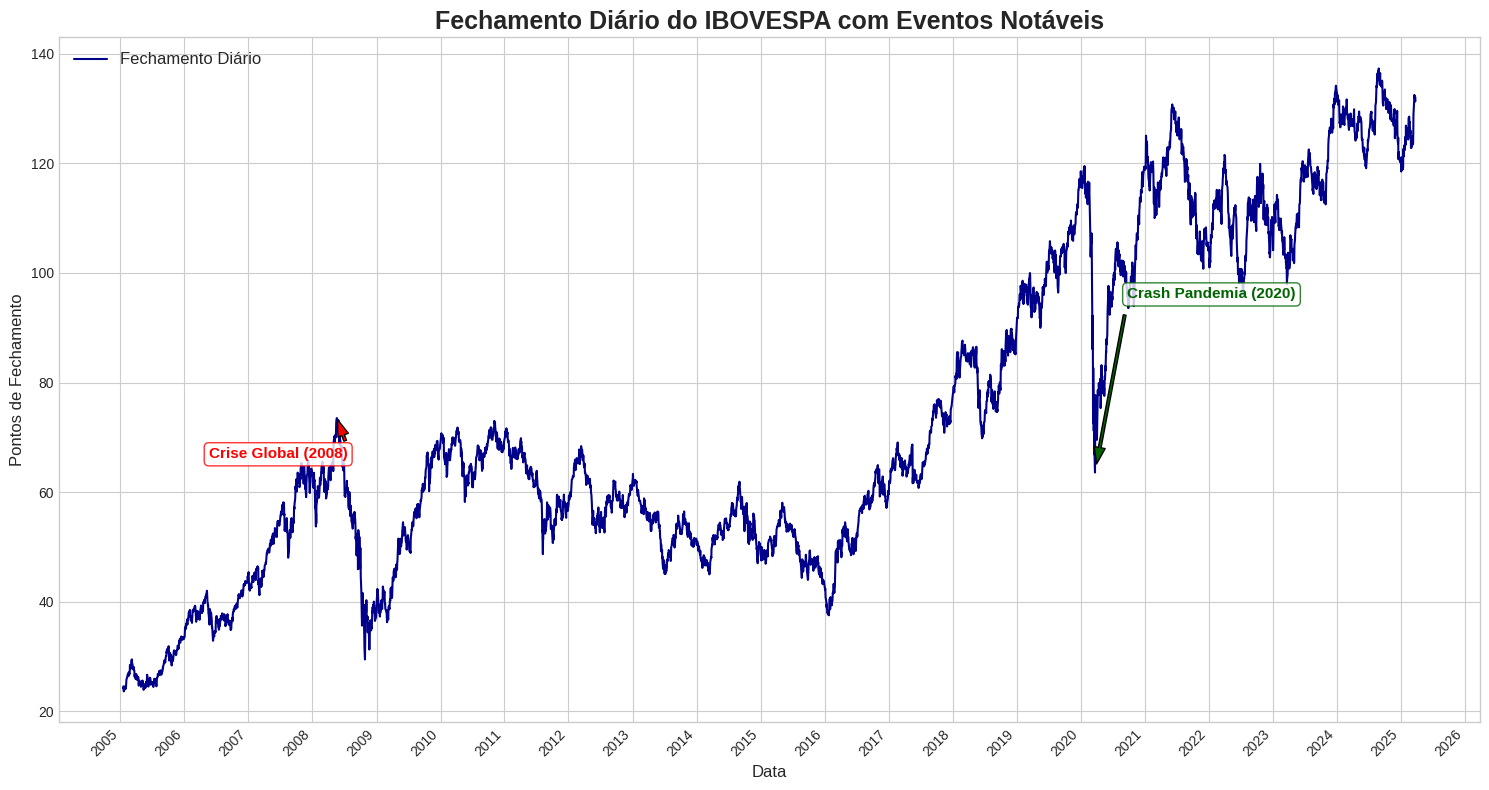

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Aplica um estilo visual mais moderno ao gráfico
plt.style.use('seaborn-v0_8-whitegrid')

# Cria a figura e os eixos (abordagem OO)
fig, ax = plt.subplots(figsize=(15, 8))

# Plota os dados nos eixos 'ax'
ax.plot(df.index, df['Último'], label='Fechamento Diário', color='darkblue', linewidth=1.5)

#  Pico de 2008 (Crise Financeira Global)
date_2008_peak = pd.to_datetime('2008-05-20') # IMPORTANTE: Ajuste esta data para o pico real no seu DF
value_2008_peak = df.loc[date_2008_peak, 'Último']

ax.annotate('Crise Global (2008)',
            xy=(date_2008_peak, value_2008_peak),
            xytext=(date_2008_peak - pd.DateOffset(years=2), value_2008_peak * 0.9),
            arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
            fontsize=11, color='red', weight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", lw=1, alpha=0.8))

#  Queda de 2020 (Pandemia)
date_2020_low = pd.to_datetime('2020-03-23') # IMPORTANTE: Ajuste esta data para o vale real no seu DF
value_2020_low = df.loc[date_2020_low, 'Último']

ax.annotate('Crash Pandemia (2020)',
            xy=(date_2020_low, value_2020_low),
            xytext=(date_2020_low + pd.DateOffset(months=6), value_2020_low * 1.5),
            arrowprops=dict(facecolor='darkgreen', shrink=0.05, width=2, headwidth=8),
            fontsize=11, color='darkgreen', weight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkgreen", lw=1, alpha=0.8))

# Formatação Automática de Datas
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

# Título e labels
ax.set_title('Fechamento Diário do IBOVESPA com Eventos Notáveis', fontsize=18, weight='bold')
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Pontos de Fechamento', fontsize=12)

# Rotaciona as labels para evitar sobreposição
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Adiciona a legenda
ax.legend(fontsize=12)

# Melhora o espaçamento para evitar que os labels sejam cortados
fig.tight_layout()

# Exibe o gráfico
plt.show()

###  **Ciclo de Expansão e a Crise de 2008**
* **Observação:** O período de 2004 a 2008 foi marcado por um forte ciclo de alta (*bull market*), que levou o índice a um pico histórico.
* **Insight:** A subsequente queda abrupta, alinhada à crise financeira global, evidencia a vulnerabilidade do mercado a choques macroeconômicos externos.

###  **Período de Volatilidade e Retomada (2009-2019)**
* **Observação:** Entre 2009 e 2016, o índice enfrentou um longo período de lateralização e alta volatilidade, sem uma tendência definida.
* **Insight:** A partir de 2017, iniciou-se uma recuperação robusta, quebrando recordes anteriores e sinalizando um novo ciclo de otimismo do mercado.

###  **A Pandemia e o Patamar Recente (2020-Presente)**
* **Observação:** O início de 2020 é definido por uma queda drástica (*crash*), reflexo da crise sanitária global. Desde 2021, o índice tem negociado em uma faixa de consolidação, majoritariamente entre **100.000 e 130.000 pontos**.
* **Insight:** O comportamento recente pode indicar uma fase de maior maturidade do mercado, com um suporte claro na região dos 100.000 pontos.

###  **Anomalias e Pontos de Atenção**
* **Observação:** O pico de 2008 e o vale de 2020 são os *outliers* mais significativos da série histórica.
* **Insight:** Estes eventos são cruciais para a modelagem. Um modelo preditivo eficaz deve ser robusto o suficiente para não ser invalidado por esses choques de alta magnitude.

In [7]:
!pip install seaborn --quiet

In [8]:
import seaborn as sns

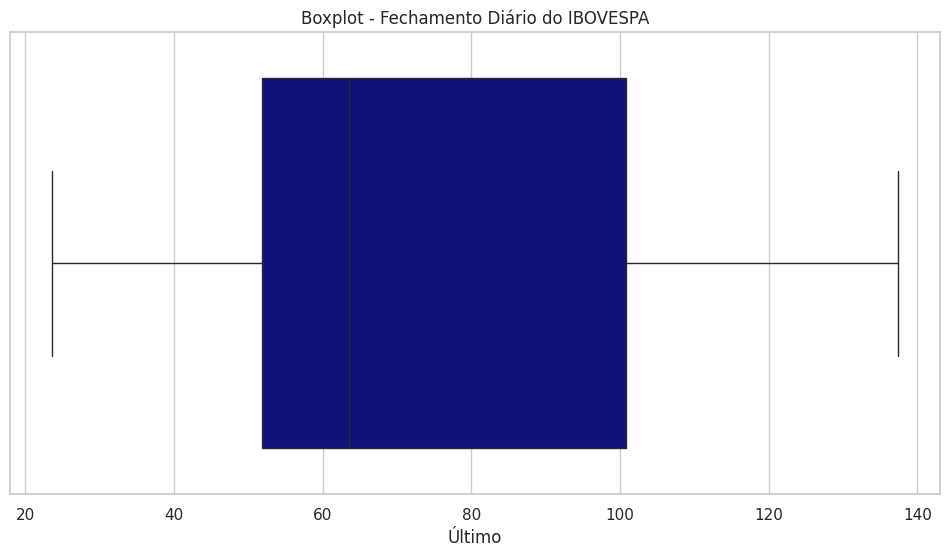

In [9]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(figsize=(12,6))
sns.boxplot(x=df['Último'], data=df, color='darkblue')
axes.set_title('Boxplot - Fechamento Diário do IBOVESPA')
plt.show()

O boxplot gerado visualiza a distribuição, a tendência central e a dispersão dos valores diários de fechamento ("Último") do IBOVESPA ao longo de todo o período analisado.

### **Mediana (Tendência Central)**
* A linha vertical dentro da caixa representa a mediana, localizada em aproximadamente **65 mil pontos**.
> **Insight:** Isso significa que em **50%** dos dias do período analisado, o IBOVESPA fechou abaixo de **65 mil pontos**, e nos outros **50%** dos dias, fechou acima deste valor.


### **Intervalo Interquartil (IQR) - O "Coração" dos Dados**
* A "caixa" azul representa o intervalo interquartil (IQR), que contém os **50% centrais** dos dados.
* O **primeiro quartil (Q1)**, borda esquerda, está em torno de **55 mil pontos**.
* O **terceiro quartil (Q3)**, borda direita, está em torno de **100 mil pontos**.
> **Insight:** Metade de todos os pregões no período tiveram um fechamento entre **55 mil e 100 mil pontos**, representando a faixa de negociação mais comum para o índice.


### **Amplitude e Dispersão (Volatilidade)**
* As linhas que se estendem da caixa (os *whiskers*) mostram a amplitude dos dados, variando de aproximadamente **25 mil a 138 mil pontos**.
> **Insight:** A grande distância entre o valor mínimo e o máximo indica uma **alta volatilidade histórica** do índice, com períodos de forte baixa e forte alta.


### **Assimetria da Distribuição (Skewness)**
* A mediana (**65k**) está visivelmente mais próxima de Q1 (**55k**) do que de Q3 (**100k**). A parte direita da caixa e seu *whisker* são mais longos.
> **Insight Chave:** Isso indica uma **forte assimetria à direita (*right-skewed*)**. Em termos de mercado, significa que, embora a maioria dos fechamentos se concentre em valores mais baixos, ocorreram períodos com picos de alta significativos que "esticam" a distribuição para a direita.


###  **Ausência de Outliers**
* Não há pontos individuais (representando outliers) plotados fora dos *whiskers*.
> **Insight:** As grandes altas e baixas (como a crise de 2008 ou o pico de 2020) fazem parte da cauda longa da distribuição, e não são consideradas anomalias estatísticas isoladas pelo critério padrão.

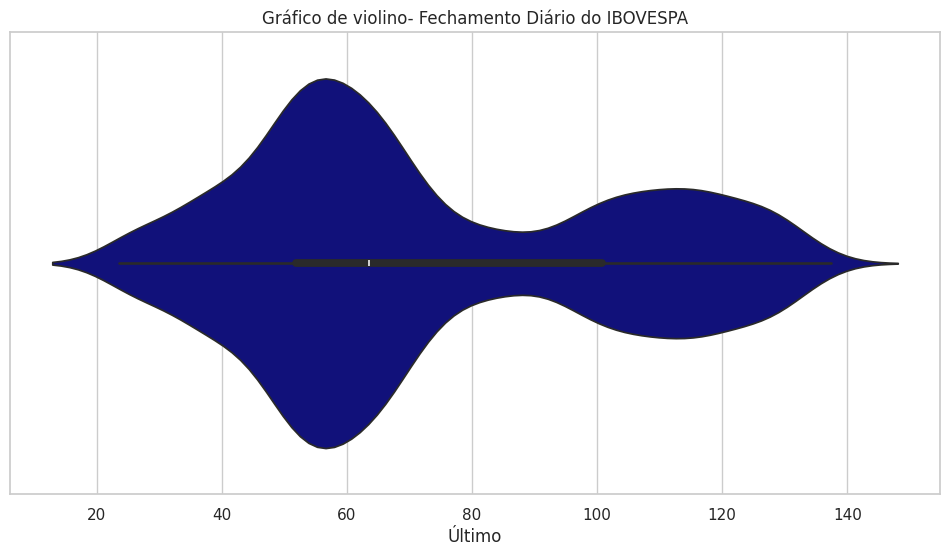

In [10]:
fig, axes = plt.subplots(figsize=(12,6))
sns.violinplot(x=df['Último'], data=df, color='darkblue')
axes.set_title('Gráfico de violino- Fechamento Diário do IBOVESPA')
plt.show()

###  **O Insight Mais Importe: A Distribuição é Bimodal**
> A característica mais marcante são os **dois "picos" ou "barrigas"** no gráfico. Um, maior, em torno de **60 mil pontos**, e outro, menor, em torno de **115 mil**.
**O que isso significa:** O IBOVESPA não se concentra em torno de um único valor central. Em vez disso, ele historicamente operou em **dois "regimes" ou "patamares" de preço principais**, um baixo e um alto, onde passou a maior parte do tempo.


### **A Faixa de Preço Mais Comum (Moda)**
* A parte mais larga do violino está na faixa de **55 a 65 mil pontos**.
**O que isso significa:** Este foi o intervalo de fechamento **mais frequente** em todo o período histórico analisado. Mais dias terminaram nesta faixa de preço do que em qualquer outra.


### **Confirmação da Assimetria à Direita**
* A "cauda" do violino do lado direito é **muito mais longa e esticada** do que a do lado esquerdo.
**O que isso significa:** Confirma o que o boxplot sugeria. Existem mais dias com valores de fechamento **"extremamente altos"** do que **"extremamente baixos"**. Períodos de forte valorização "esticaram" a distribuição para a direita.


### **Alta Volatilidade Histórica**
* O comprimento total do violino, que vai de aproximadamente **25 mil a quase 140 mil pontos**, é muito grande.
**O que isso significa:** A enorme amplitude entre o valor mínimo e máximo registrados visualiza a **alta volatilidade** do índice ao longo dos anos.


### **Zonas de Transição com Menor Frequência**
* As partes mais "magras" ou "apertadas" do violino, como a região entre **80 e 90 mil pontos**, representam valores menos comuns.
**O que isso significa:** O IBOVESPA passou **menos tempo** negociando nesses níveis. Eles funcionaram mais como **zonas de transição** entre os dois principais patamares de preço.

In [11]:
# Cria novas colunas baseadas no índice de data
df['Ano'] = df.index.year
df['Mes'] = df.index.month
df['Dia'] = df.index.day
df['Semana_do_ano'] = df.index.isocalendar().week.astype(int)
df['Dia_da_semana'] = df.index.dayofweek
print(df.head())



            Último  Abertura  Máxima  Mínima         Vol.  Var%   Ano  Mes  \
Data                                                                         
2005-01-17  24.515    24.924  25.022  24.515   75060000.0 -1.64  2005    1   
2005-01-18  24.089    24.515  24.515  24.019  179420000.0 -1.74  2005    1   
2005-01-19  24.271    24.091  24.465  24.091  113110000.0  0.76  2005    1   
2005-01-20  23.610    24.271  24.271  23.534  182060000.0 -2.72  2005    1   
2005-01-21  23.818    23.618  24.006  23.609   97400000.0  0.88  2005    1   

            Dia  Semana_do_ano  Dia_da_semana  
Data                                           
2005-01-17   17              3              0  
2005-01-18   18              3              1  
2005-01-19   19              3              2  
2005-01-20   20              3              3  
2005-01-21   21              3              4  


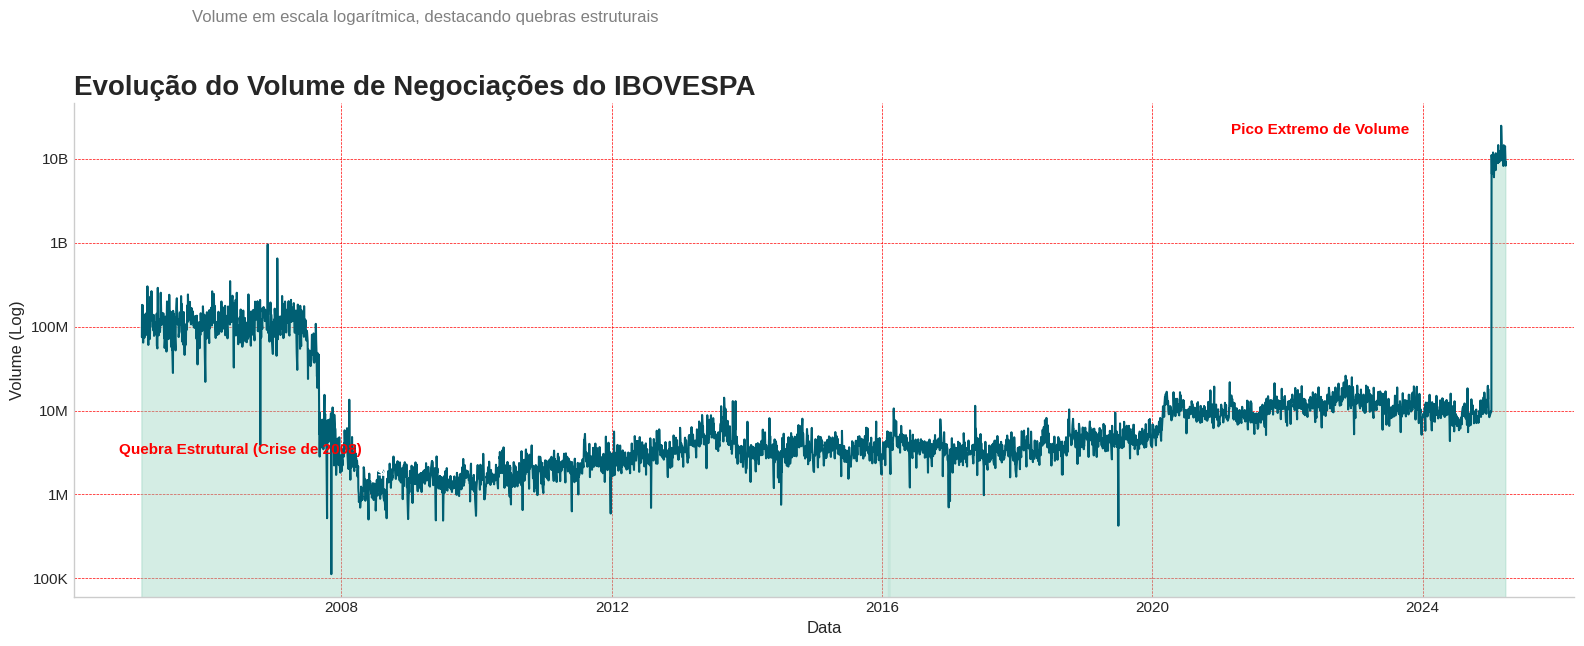

In [12]:
from matplotlib.ticker import FuncFormatter

def plotar_volume(df):

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(16, 7))

    line_color = '#005f73' # Um tom de azul-petróleo
    fill_color = '#94d2bd' # Um tom de verde-água claro

    # Plota a linha principal
    sns.lineplot(x=df.index, y="Vol.", data=df, ax=ax, color=line_color, linewidth=1.5)

    # Adiciona a área preenchida abaixo da linha
    ax.fill_between(df.index, df['Vol.'], color=fill_color, alpha=0.4)

    # Quebra de 2008
    date_2008_break = pd.to_datetime('2008-09-15') # Data aproximada da quebra
    ax.annotate('Quebra Estrutural (Crise de 2008)',
                xy=(date_2008_break, df.loc[date_2008_break:, 'Vol.'].iloc[0]),
                xytext=(date_2008_break - pd.DateOffset(years=4), 3e6),
                arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle='arc3,rad=-0.2'),
                fontsize=11, weight='bold', color='red')

    # Pico de 2024/2025
    peak_date = df['Vol.'].idxmax() # Encontra a data do volume máximo automaticamente
    peak_value = df['Vol.'].max()
    ax.annotate('Pico Extremo de Volume',
                xy=(peak_date, peak_value),
                xytext=(peak_date - pd.DateOffset(years=4), peak_value * 0.8),
                arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle='arc3,rad=0.2'),
                fontsize=11, weight='bold', color='red')

    ax.set_title("Evolução do Volume de Negociações do IBOVESPA", loc="left", fontsize=20, weight='bold')
    fig.suptitle("Volume em escala logarítmica, destacando quebras estruturais", x=0.125, y=0.92, ha='left', fontsize=12, color='gray')
    ax.set_xlabel("Data", fontsize=12)
    ax.set_ylabel("Volume (Log)", fontsize=12)

    ax.set_yscale('log')

    def millions_formatter(x, pos):
        if x >= 1e9:
            return f'{int(x/1e9)}B' # Adiciona formato para Bilhões
        if x >= 1e6:
            return f'{int(x/1e6)}M' # Milhões
        if x >= 1e3:
            return f'{int(x/1e3)}K' # Milhares
        return str(int(x))

    ax.get_yaxis().set_major_formatter(FuncFormatter(millions_formatter))

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='red')

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

plotar_volume(df)


>Este gráfico mostra a evolução do volume financeiro negociado ao longo do tempo. A escala do eixo Y (Volume) é **logarítmica**, o que significa que cada marca principal representa um aumento de 10x, ajudando a visualizar variações de grande magnitude.

### **Quebra Estrutural Pós-2008**
* **Observação:** Há uma queda abrupta e massiva no volume de negociações em **2008**. O patamar, que estava na casa das **centenas de milhões**, cai drasticamente para a casa das **unidades ou dezenas de milhões**.
* **O que isso significa:** A crise financeira global de 2008 não impactou apenas o preço, mas causou uma **mudança estrutural no volume de negociação** do mercado, que levou quase uma década para começar a se recuperar.

### **Lenta Recuperação e Novo Aumento**
* **Observação:** De 2009 até aproximadamente 2018, o volume permaneceu em um patamar baixo e estável. A partir daí, nota-se um **crescimento gradual e consistente**.
* **O que isso significa:** O mercado levou muito tempo para recuperar a liquidez.
### **Anomalia Extrema em 2024-2025**
* **Observação:** No final do período do gráfico, há um pico de volume extremo, quase vertical, ultrapassando a marca de **10.000M (10 Bilhões)**.
* **O que isso significa:** Este é um **ponto de atenção crítico**. Pode indicar um evento de mercado extraordinário.

-> Gerando gráfico aprimorado: Ibovespa com Médias Móveis...


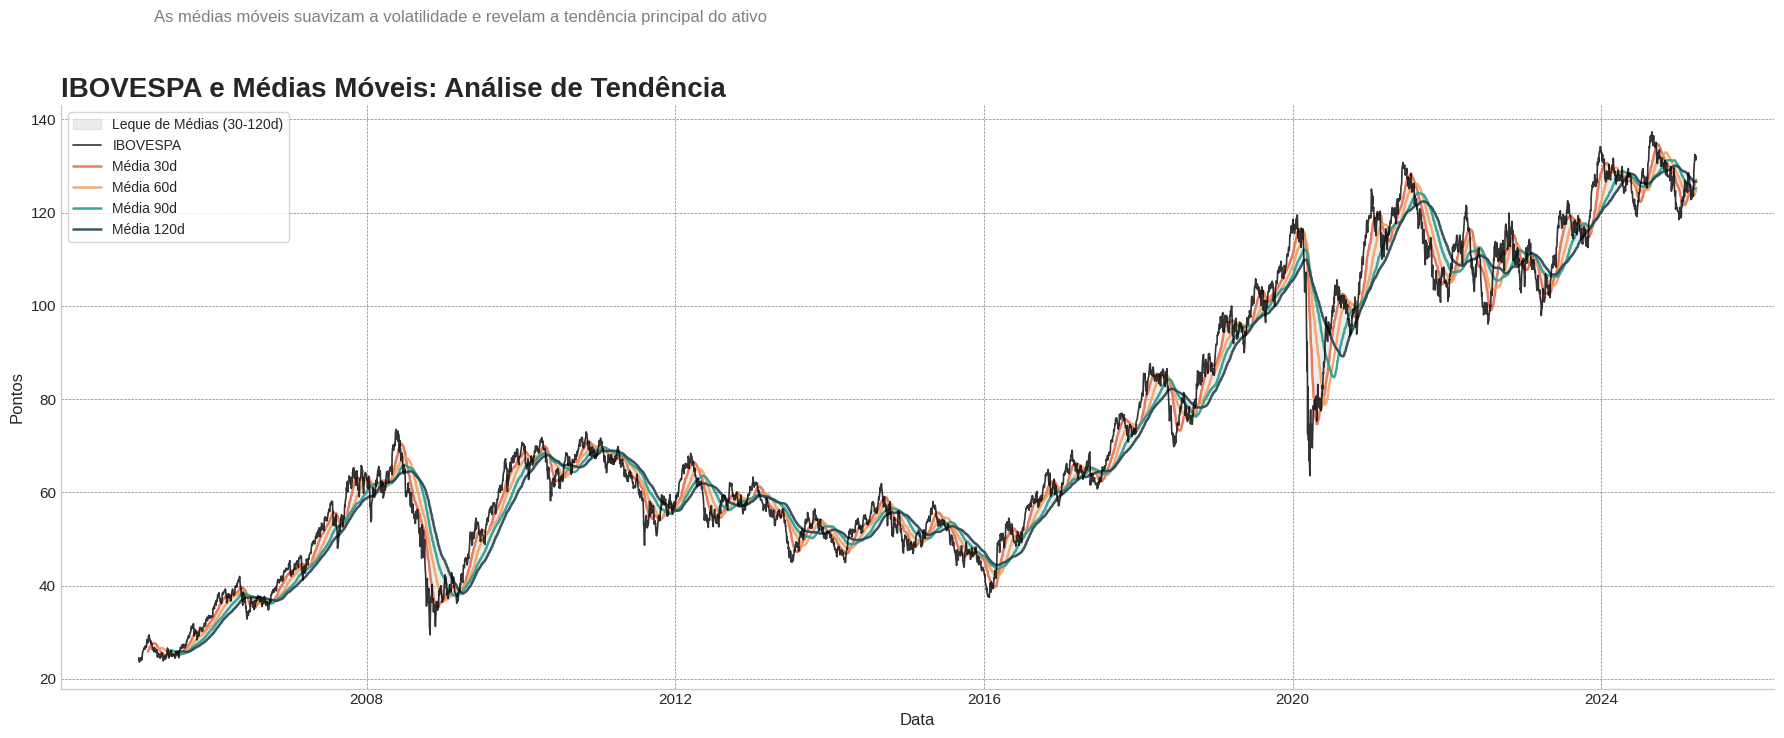

In [13]:
def plotar_ibov_medias(df):
    """
    Gráfico do Ibovespa com médias móveis (30, 60, 90, 120 dias)
    com estilo visual aprimorado e fita de tendência.
    """
    print("-> Gerando gráfico aprimorado: Ibovespa com Médias Móveis...")

    df_plot = df.copy()
    windows = [30, 60, 90, 120]
    for w in windows:
        df_plot[f"SMA_{w}"] = df_plot["Último"].rolling(w).mean()

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(18, 8))

    # Cores quentes para médias curtas (rápidas), frias para longas (lentas)
    colors = {30: '#e76f51', 60: '#f4a261', 90: '#2a9d8f', 120: '#264653'}

    # Cria uma área sombreada entre a média mais rápida e a mais lenta
    ax.fill_between(df_plot.index, df_plot['SMA_30'], df_plot['SMA_120'],
                    color='gray', alpha=0.15, label='Leque de Médias (30-120d)')
    # Usamos ax.plot para mais controle, como o zorder (camada de desenho)
    ax.plot(df_plot.index, df_plot["Último"], color='black', linewidth=1.2,
            alpha=0.8, label="IBOVESPA", zorder=5)

    # Plota as médias móveis com as cores e estilos definidos
    for w in windows:
        ax.plot(df_plot.index, df_plot[f"SMA_{w}"], color=colors[w],
                linewidth=1.8, alpha=0.9, label=f"Média {w}d")

    # Títulos, legendas e grid aprimorados
    ax.set_title("IBOVESPA e Médias Móveis: Análise de Tendência", loc="left", fontsize=20, weight='bold')
    fig.suptitle("As médias móveis suavizam a volatilidade e revelam a tendência principal do ativo",
                 x=0.09, y=0.92, ha='left', fontsize=12, color='gray')

    ax.set_xlabel("Data", fontsize=12)
    ax.set_ylabel("Pontos", fontsize=12)

    # Posiciona a legenda para não atrapalhar o gráfico
    ax.legend(loc='upper left', frameon=True, fontsize=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

plotar_ibov_medias(df)


> As médias móveis suavizam o "ruído" diário e ajudam a identificar a tendência principal do ativo.

### **Identificação Clara de Tendências (Bull vs. Bear Market)**
* **Observação:** O preço permanece consistentemente **acima** de todas as médias em períodos como 2016-2018 e pós-2020. Em 2008, o preço cruza para **baixo** de todas elas.
* **O que isso significa:** Preço acima das médias confirma um **mercado de alta (bull market)**. Preço abaixo confirma um **mercado de baixa (bear market)**.

###  **Médias como Suporte e Resistência Dinâmicos**
* **Observação:** Em uma tendência de alta, o preço frequentemente "cai" até tocar em uma das médias e depois volta a subir.
* **O que isso significa:** As linhas das médias atuam como **níveis de suporte (na alta) ou resistência (na baixa)** que se movem junto com o preço.



-> Gerando gráfico: Heatmap de Correlação...


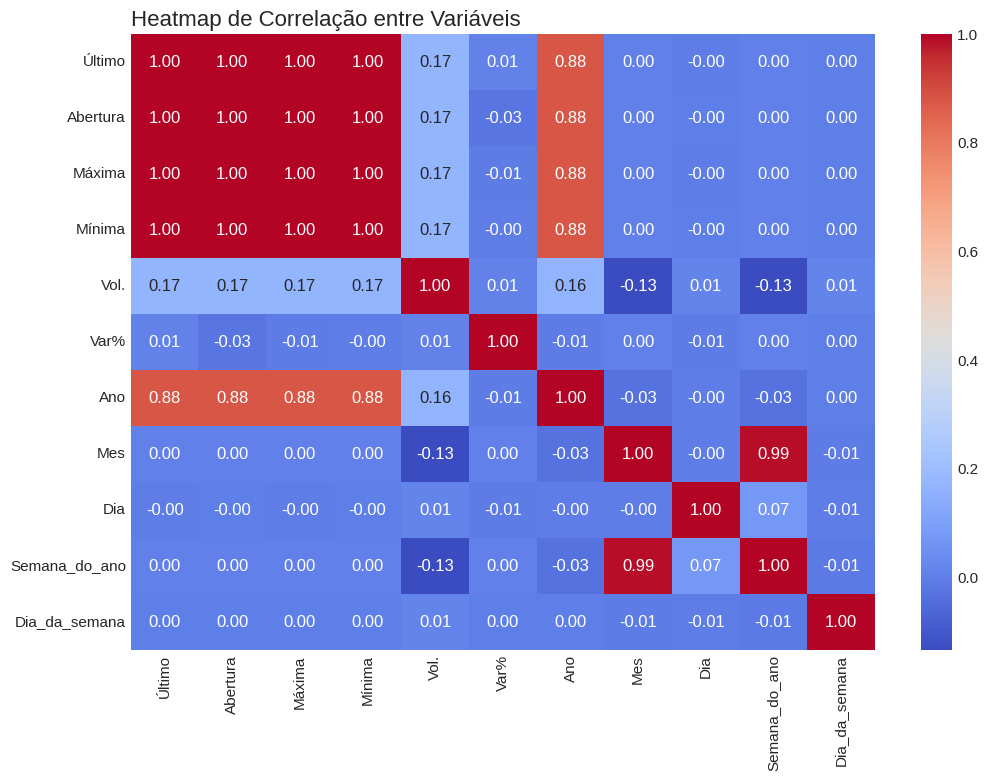

In [14]:
def plotar_heatmap(df):
    """Heatmap de correlação entre variáveis numéricas."""
    print("-> Gerando gráfico: Heatmap de Correlação...")
    plt.figure(figsize=(12, 8))
    # Esta função já seleciona colunas numéricas automaticamente, então não precisa de ajuste
    num_attributes = df.select_dtypes(include=['int64', 'float64', 'int32', 'UInt32'])
    sns.heatmap(num_attributes.corr(method='pearson'), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Heatmap de Correlação entre Variáveis", loc="left", fontsize=16)
    plt.show()

plotar_heatmap(df)


> O heatmap visualiza a força da relação linear entre as variáveis. Vermelho (próximo de 1) é correlação positiva forte; azul (próximo de -1) é correlação negativa forte.

###  **Altíssima Correlação entre Preços de Referência**
* **Observação:** As variáveis `Último`, `Abertura`, `Máxima` e `Mínima` têm correlação de **1.00** entre si.
* **O que isso significa:** É o esperado. Para modelagem, usar todas elas pode causar **multicolinearidade**.

### **Forte Tendência de Longo Prazo**
* **Observação:** A variável `Ano` tem uma correlação positiva muito forte (**0.88**) com os preços.
* **O que isso significa:** Isso captura numericamente a **tendência de alta do IBOVESPA ao longo dos anos**.

### **Ausência de Relações Sazonais Simples**
* **Observação:** `Mes`, `Dia`, `Semana_do_ano` e `Dia_da_semana` têm correlações muito próximas de **zero** com o `Último`.
* **O que isso significa:** Não existe uma relação linear simples e direta entre o preço e o dia da semana ou o mês do ano.

In [15]:
!pip install scipy --quiet

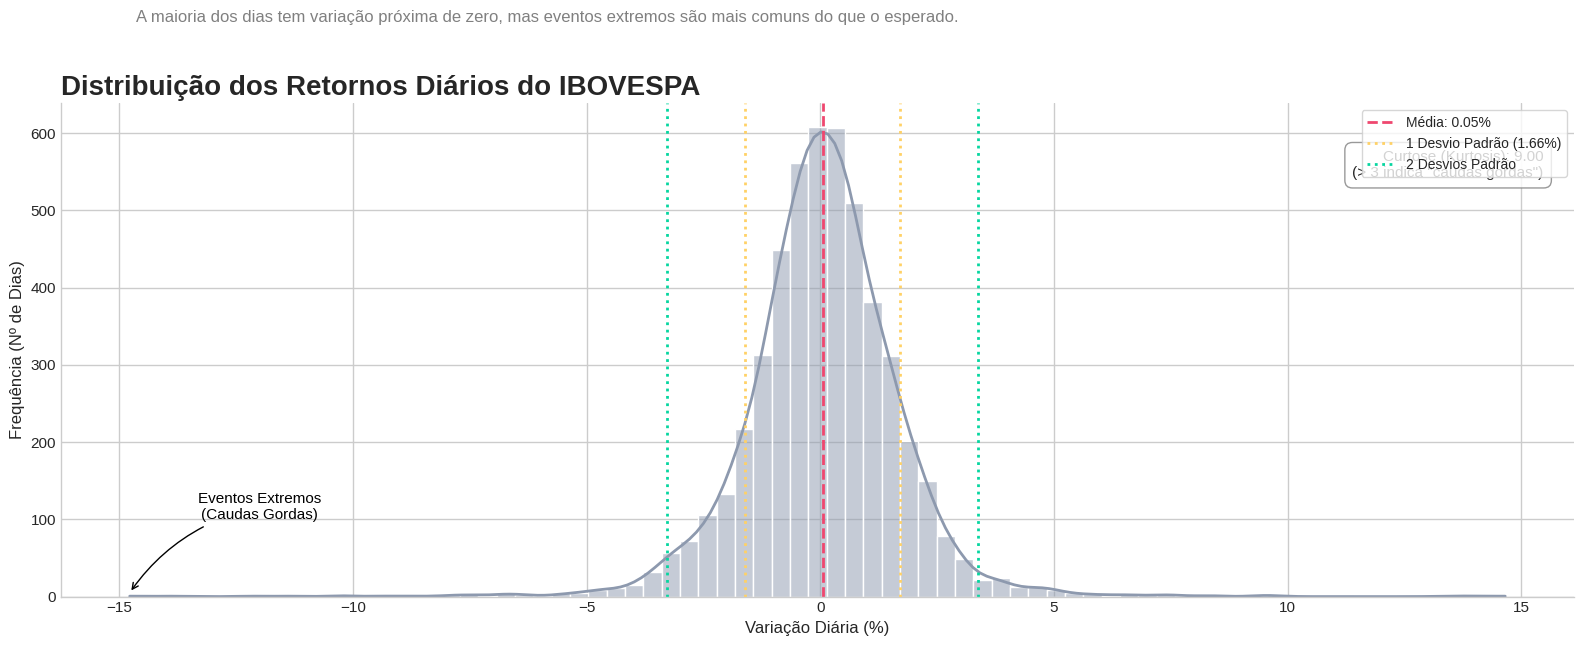

In [16]:

from scipy import stats # Para obter a curtose (kurtosis)

def plotar_distribuicao(df):

    df_plot = df.copy()
    df_plot["return"] = df_plot["Último"].pct_change() * 100
    returns = df_plot["return"].dropna()
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(16, 7))

    # Histograma com KDE e cores personalizadas
    sns.histplot(returns, bins=75, kde=True, ax=ax,
                 line_kws={'linewidth': 2, 'color': '#d90429'}, # Linha do KDE
                 color='#8d99ae') # Cor das barras

    # Adicionar linhas verticais para estatísticas
    mean = returns.mean()
    std = returns.std()

    # Linha da Média
    ax.axvline(mean, color='#ef476f', linestyle='--', linewidth=2, label=f'Média: {mean:.2f}%')

    # Linhas para 1 e 2 desvios-padrão
    ax.axvline(mean + std, color='#ffd166', linestyle=':', linewidth=2, label=f'1 Desvio Padrão ({std:.2f}%)')
    ax.axvline(mean - std, color='#ffd166', linestyle=':', linewidth=2)
    ax.axvline(mean + 2*std, color='#06d6a0', linestyle=':', linewidth=2, label=f'2 Desvios Padrão')
    ax.axvline(mean - 2*std, color='#06d6a0', linestyle=':', linewidth=2)

    # Anotação sobre as "Caudas Gordas"
    kurt = stats.kurtosis(returns)
    ax.text(0.98, 0.85, f'Curtose (Kurtosis): {kurt:.2f}\n(> 3 indica "caudas gordas")',
            transform=ax.transAxes, fontsize=11, ha='right',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='gray', lw=1, alpha=0.8))

    # Destaque para as caudas
    ax.annotate('Eventos Extremos\n(Caudas Gordas)', xy=(returns.min(), 5),
                xytext=(-12, 100), arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", color='black'),
                fontsize=11, color='black', ha='center')

    # Títulos, labels e aparência
    ax.set_title("Distribuição dos Retornos Diários do IBOVESPA", loc="left", fontsize=20, weight='bold')
    fig.suptitle("A maioria dos dias tem variação próxima de zero, mas eventos extremos são mais comuns do que o esperado.",
                 x=0.09, y=0.92, ha='left', fontsize=12, color='gray')

    ax.set_xlabel("Variação Diária (%)", fontsize=12)
    ax.set_ylabel("Frequência (Nº de Dias)", fontsize=12)

    ax.legend(loc='upper right', frameon=True, fontsize=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()


plotar_distribuicao(df)


> Este histograma mostra a distribuição dos retornos diários. Ele nos diz qual é a "normalidade" das flutuações do mercado.

###  **Forte Concentração em Torno de Zero**
* **Observação:** A grande maioria dos dias se concentra em uma variação muito próxima de **0%** (entre -1% e +1%).
* **O que isso significa:** O comportamento mais comum do mercado é ter **pequenas variações diárias**. Grandes oscilações são eventos mais raros.

###  **"Caudas Gordas" (Fat Tails)**
* **Observação:** Embora raras, o gráfico mostra a ocorrência de variações extremas, chegando a **-10% e +10%** em um único dia.
* **O que isso significa:** Eventos extremos (quedas bruscas ou altas repentinas) são **mais prováveis no mercado financeiro** do que em um modelo estatístico normal. Isso é conhecido como **leptocurtose**.

/tmp/ipython-input-3078005204.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Ano", y="Último", data=df_plot, ax=ax, palette="viridis")


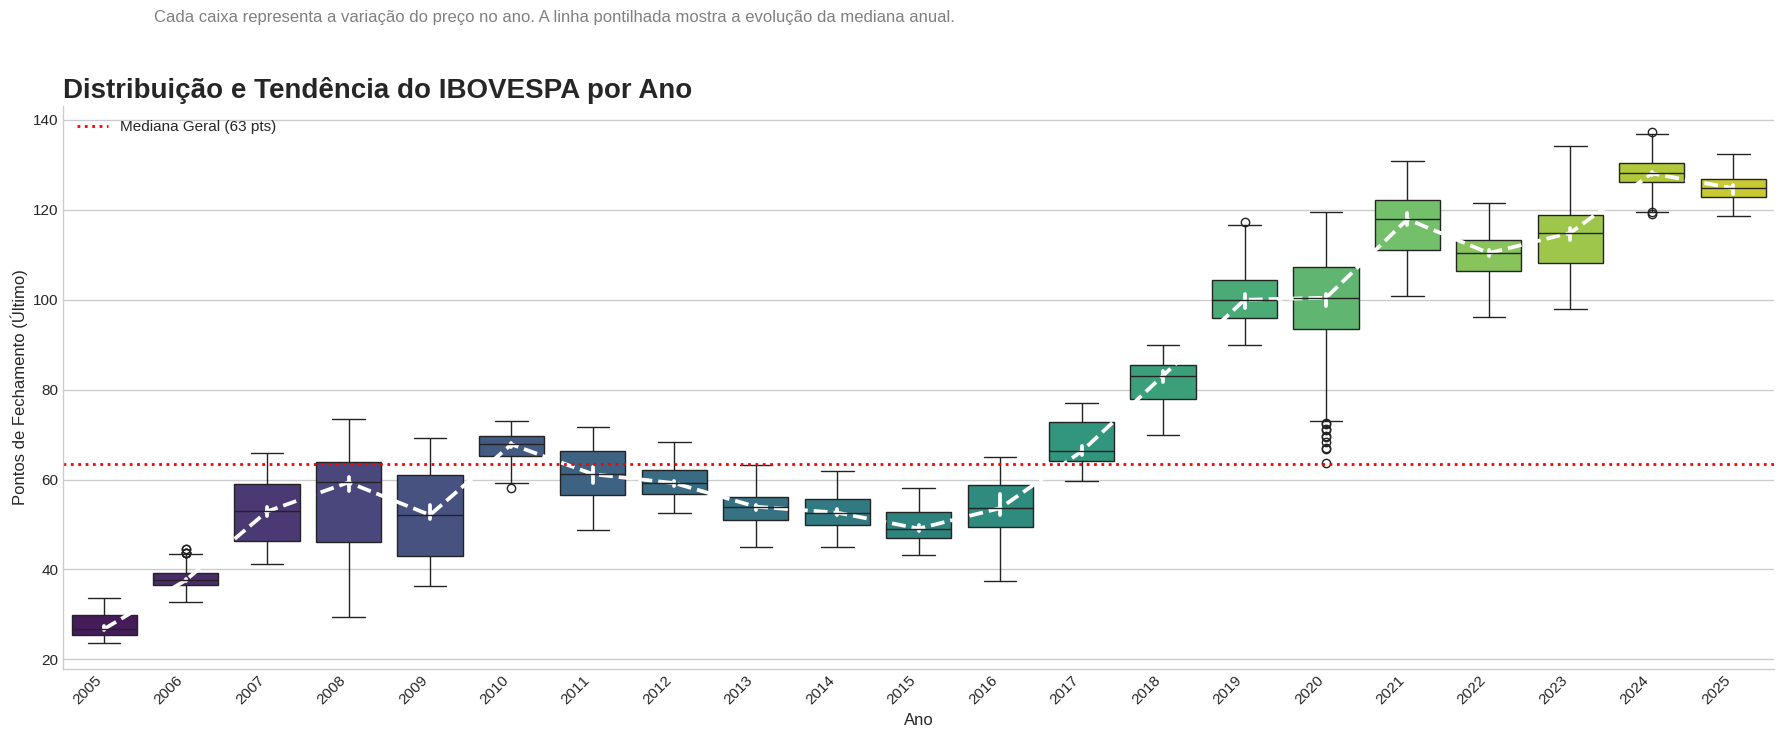

In [17]:
import pandas as pd
import numpy as np


def plotar_boxplot(df):

    df_plot = df.copy()
    # Garante que a coluna 'Ano' exista a partir do índice
    if 'Ano' not in df_plot.columns:
        df_plot['Ano'] = df_plot.index.year

    # Estilo, Cores e Figura Maior
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(18, 8))

    # Usa uma paleta de cores que evolui com o tempo (anos mais recentes mais escuros)
    sns.boxplot(x="Ano", y="Último", data=df_plot, ax=ax, palette="viridis")

    # Sobrepor um pointplot para destacar a tendência das medianas
    # Isso cria uma linha conectando a mediana de cada ano, evidenciando a tendência
    sns.pointplot(x="Ano", y="Último", data=df_plot, ax=ax,
                  estimator=np.median, # Garante que estamos conectando as medianas
                  color="white",
                  linestyles='--',
                  markersize=0) # Remove os marcadores, deixando só a linha

    #Adicionar uma linha de referência da mediana geral
    median_geral = df['Último'].median()
    ax.axhline(median_geral, color='red', linestyle=':', linewidth=2,
               label=f'Mediana Geral ({median_geral:,.0f} pts)'.replace(',', '.'))

    # Títulos e acabamento
    ax.set_title("Distribuição e Tendência do IBOVESPA por Ano", loc="left", fontsize=20, weight='bold')
    fig.suptitle("Cada caixa representa a variação do preço no ano. A linha pontilhada mostra a evolução da mediana anual.",
                 x=0.09, y=0.92, ha='left', fontsize=12, color='gray')

    ax.set_xlabel("Ano", fontsize=12)
    ax.set_ylabel("Pontos de Fechamento (Último)", fontsize=12)
    plt.xticks(rotation=45, ha='right') # Rotação de 45° é mais legível que 90°
    ax.legend()

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()



plotar_boxplot(df)


> Este gráfico mostra a distribuição do preço de fechamento para cada ano, permitindo comparar a volatilidade e a tendência ao longo do tempo.

###  **Mudança de Patamar de Preços**
* **Observação:** Até 2018, o IBOVESPA negociava majoritariamente abaixo dos 80 mil pontos. A partir de 2019, o índice passou a operar em um novo patamar, **acima dos 100 mil pontos**.
* **O que isso significa:** Ocorreu uma **reprecificação estrutural** do mercado.

###  **Volatilidade Visível**
* **Observação:** O tamanho das caixas e dos "bigodes" varia muito. Anos como **2008** e **2020** são visivelmente mais longos.
* **O que isso significa:** O tamanho do boxplot em um ano é um indicador da **volatilidade**. 2008 (crise global) e 2020 (pandemia) foram anos de **altíssima instabilidade**.

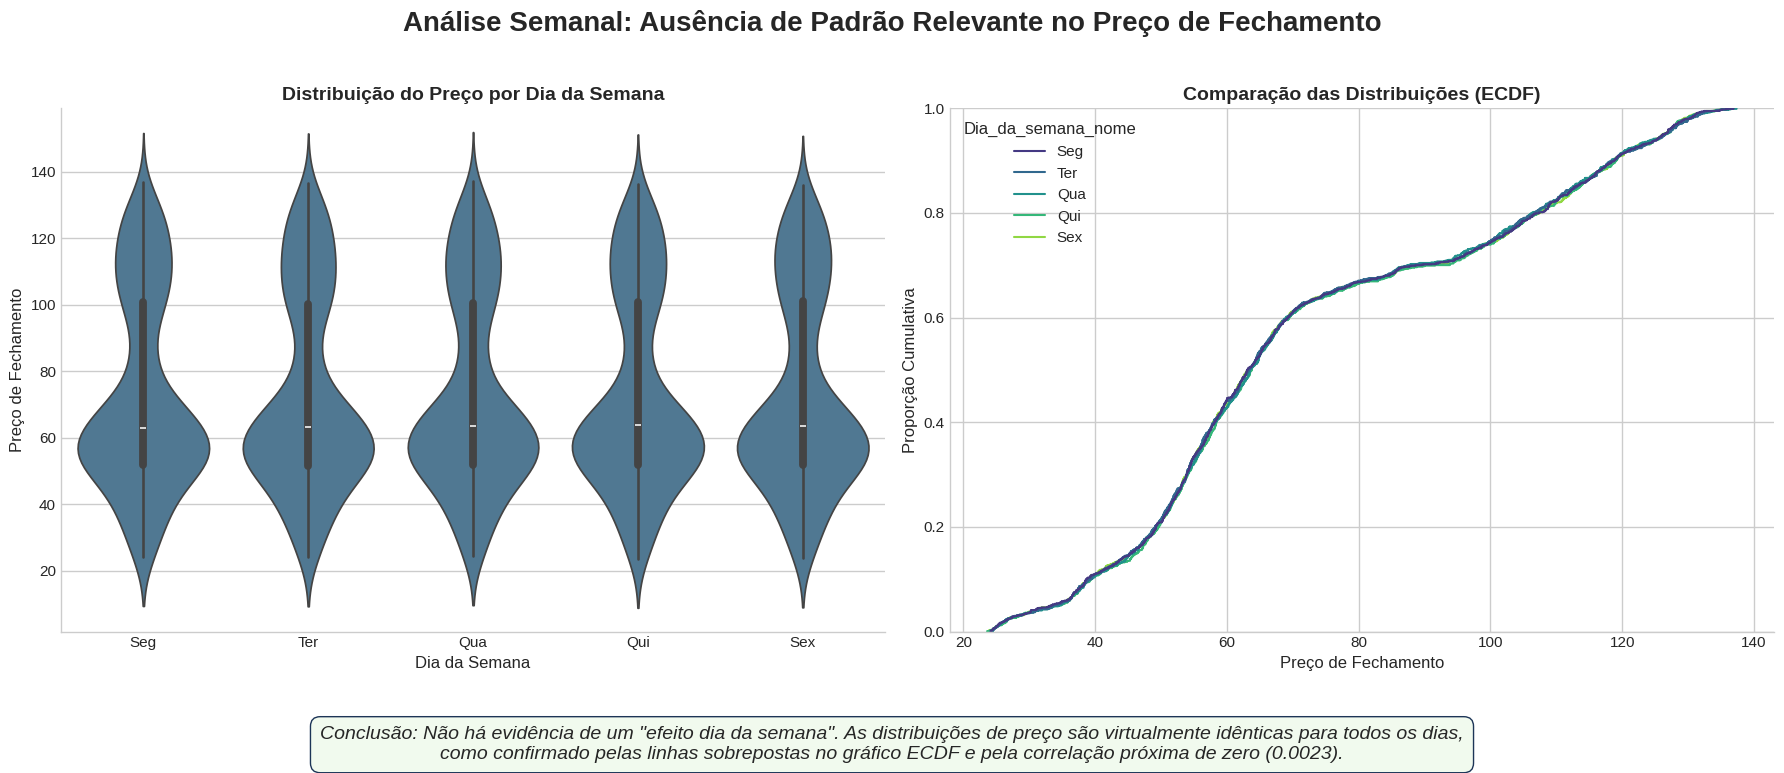

In [18]:
def analisar_por_dia_semana(df):

    dias_semana = {0: 'Seg', 1: 'Ter', 2: 'Qua', 3: 'Qui', 4: 'Sex'}
    df_plot = df.copy()
    # Garante que os dias da semana estejam ordenados no gráfico
    df_plot['Dia_da_semana_nome'] = df_plot['Dia_da_semana'].map(dias_semana)
    dias_ordenados = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex']

    #Estilo e Figura
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(18, 7)) # Reduzido para 2 gráficos principais

    # O Violinplot combina o boxplot com a distribuição de densidade (KDE), sendo mais informativo.
    sns.violinplot(x='Dia_da_semana_nome', y='Último', data=df_plot, ax=axes[0],
                   order=dias_ordenados, color='#457b9d', inner='box')
    axes[0].set_title('Distribuição do Preço por Dia da Semana', fontsize=14, weight='bold')
    axes[0].set_xlabel('Dia da Semana', fontsize=12)
    axes[0].set_ylabel('Preço de Fechamento', fontsize=12)

    # Gráfico ECDF no lugar da Média e Heatmap
    # O ECDF (Função de Distribuição Cumulativa Empírica) é excelente para comparar distribuições.
    # Se as linhas estiverem sobrepostas, as distribuições são idênticas.
    sns.ecdfplot(data=df_plot, x='Último', hue='Dia_da_semana_nome', ax=axes[1],
                 hue_order=dias_ordenados, palette='viridis')
    axes[1].set_title('Comparação das Distribuições (ECDF)', fontsize=14, weight='bold')
    axes[1].set_xlabel('Preço de Fechamento', fontsize=12)
    axes[1].set_ylabel('Proporção Cumulativa', fontsize=12)

    #Título principal e Anotação com a Conclusão
    fig.suptitle('Análise Semanal: Ausência de Padrão Relevante no Preço de Fechamento',
                 fontsize=20, weight='bold', y=1.02)

    # Adiciona um texto conclusivo diretamente na figura
    corr_value = df[['Dia_da_semana', 'Último']].corr().iloc[0, 1]
    fig.text(0.5, -0.05,
             f'Conclusão: Não há evidência de um "efeito dia da semana". As distribuições de preço são virtualmente idênticas para todos os dias,\n'
             f'como confirmado pelas linhas sobrepostas no gráfico ECDF e pela correlação próxima de zero ({corr_value:.4f}).',
             ha='center', fontsize=14, style='italic',
             bbox=dict(boxstyle='round,pad=0.5', fc='#f1faee', ec='#1d3557', lw=1))


    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout(rect=[0, 0.05, 1, 1]) # Ajusta o layout para dar espaço à conclusão
    plt.show()


analisar_por_dia_semana(df)


> Estes gráficos analisam se o dia da semana tem alguma influência sobre o preço de fechamento.

###  **Ausência de Padrão Semanal Relevante**
* **Observação:** A **média de preço é idêntica** para todos os dias, a **distribuição nos boxplots é similar** e a **correlação é zero (0.0023)**.
* **O que isso significa:** Com base nos dados históricos, **não existe um "efeito dia da semana"** previsível e estatisticamente relevante no IBOVESPA.


/tmp/ipython-input-3414399698.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Mes_nome', y='Último', data=df_plot, ax=axes[0],


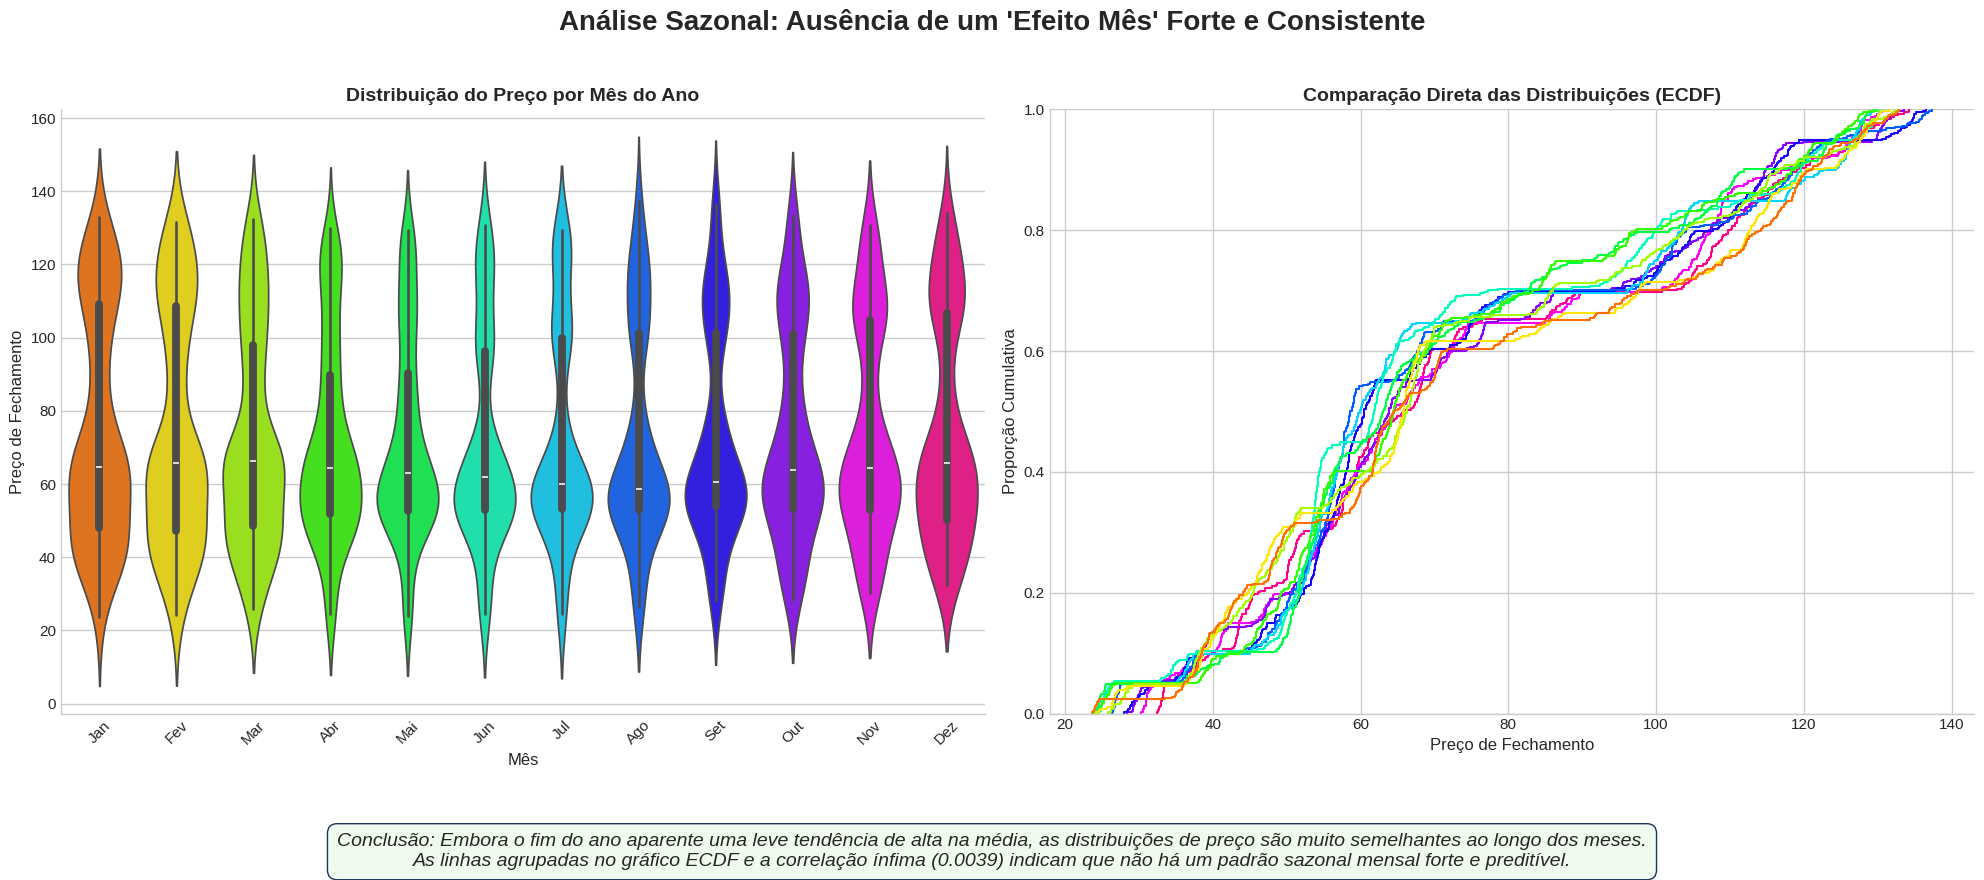

In [19]:
def analisar_por_mes(df):
    meses_nomes = {
        1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
        7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
    }
    df_plot = df.copy()
    # Cria uma coluna com os nomes dos meses para facilitar a plotagem e ordenação
    df_plot['Mes_nome'] = df_plot['Mes'].map(meses_nomes)
    meses_ordenados = list(meses_nomes.values())

    # Estilo e Figura
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # O Violinplot mostra a forma da distribuição para cada mês.
    sns.violinplot(x='Mes_nome', y='Último', data=df_plot, ax=axes[0],
                   order=meses_ordenados, palette='hsv', inner='box')
    axes[0].set_title('Distribuição do Preço por Mês do Ano', fontsize=14, weight='bold')
    axes[0].set_xlabel('Mês', fontsize=12)
    axes[0].set_ylabel('Preço de Fechamento', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)

    # Se as linhas estiverem muito próximas, as distribuições são semelhantes.
    sns.ecdfplot(data=df_plot, x='Último', hue='Mes_nome', ax=axes[1],
                 hue_order=meses_ordenados, palette='hsv')
    axes[1].set_title('Comparação Direta das Distribuições (ECDF)', fontsize=14, weight='bold')
    axes[1].set_xlabel('Preço de Fechamento', fontsize=12)
    axes[1].set_ylabel('Proporção Cumulativa', fontsize=12)
    axes[1].get_legend().remove() # Remove a legenda para não poluir

    # Título principal e Anotação com a Conclusão
    fig.suptitle("Análise Sazonal: Ausência de um 'Efeito Mês' Forte e Consistente",
                 fontsize=20, weight='bold', y=1.02)

    # Adiciona um texto conclusivo diretamente na figura
    corr_value = df[['Mes', 'Último']].corr().iloc[0, 1]
    fig.text(0.5, -0.05,
             f'Conclusão: Embora o fim do ano aparente uma leve tendência de alta na média, as distribuições de preço são muito semelhantes ao longo dos meses.\n'
             f'As linhas agrupadas no gráfico ECDF e a correlação ínfima ({corr_value:.4f}) indicam que não há um padrão sazonal mensal forte e preditível.',
             ha='center', fontsize=14, style='italic',
             bbox=dict(boxstyle='round,pad=0.5', fc='#f1faee', ec='#1d3557', lw=1))

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


analisar_por_mes(df)


> Esta análise busca por padrões sazonais, ou seja, se certos meses são consistentemente melhores ou piores.

### **Insight Chave: Ausência de Sazonalidade Mensal Clara e Forte**
* **Observação:** As médias entre os meses são muito próximas, os boxplots são similares e a correlação é **zero (0.0039)**.
* **O que isso significa:** Assim como na análise semanal, **não há um efeito sazonal mensal forte e confiável** no histórico completo. Nenhum mês se destaca como um previsor confiável de alta ou baixa.

/tmp/ipython-input-3938095010.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Vol_bins', y='Último', data=aux_df, ax=axes[1], palette='viridis', inner='box')


ERRO ao gerar análise por volume: keyword ha is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap'

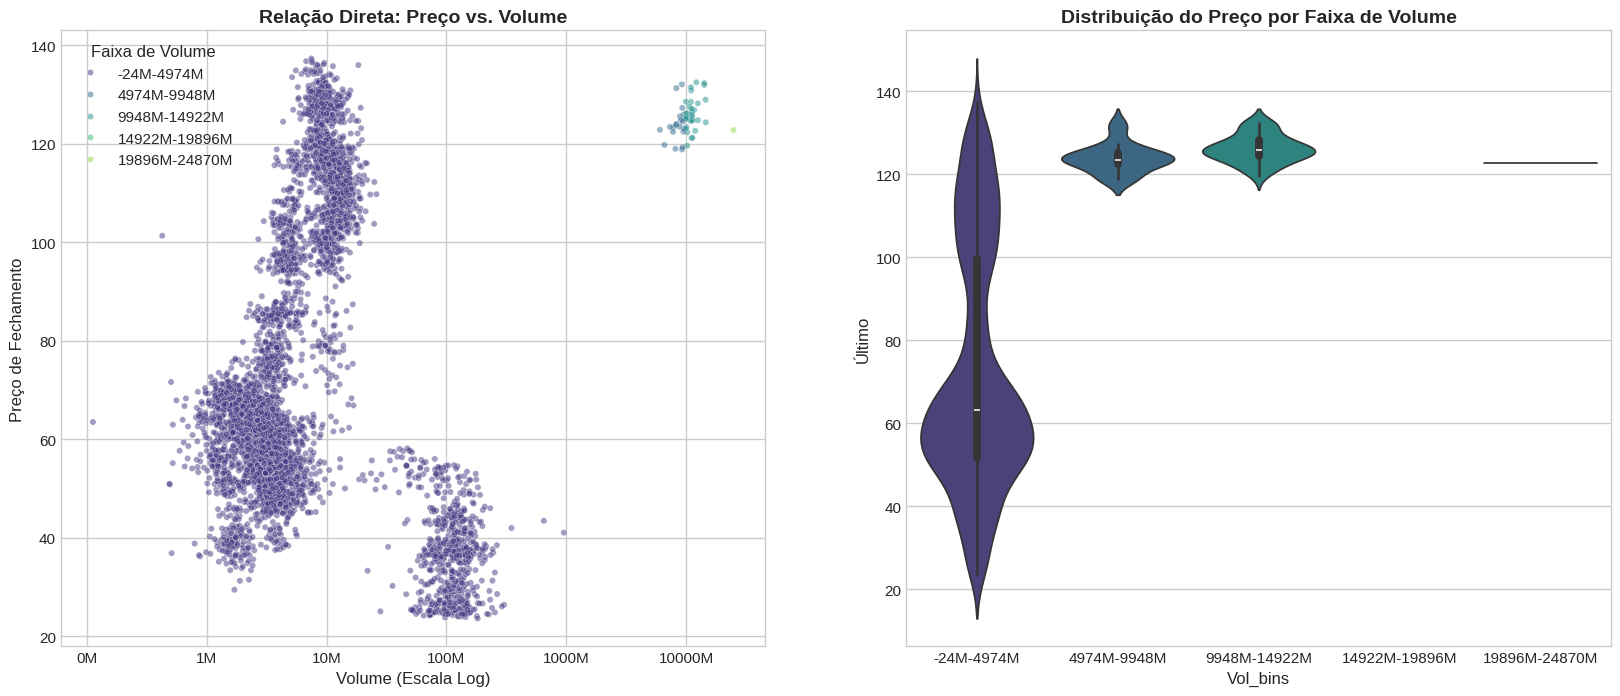

In [20]:
def analisar_por_volume(df):

    try:
        aux_df = df[['Vol.', 'Último']].dropna()
        if aux_df.shape[0] < 50: # Aumentado o limite para uma análise mais robusta
            print("AVISO: Dados insuficientes para análise de volume.")
            return

        # Criamos os bins e depois geramos rótulos mais legíveis para eles
        bins = pd.cut(aux_df['Vol.'], bins=5, duplicates='drop')
        labels = [f'{int(b.left/1e6)}M-{int(b.right/1e6)}M' for b in bins.cat.categories]
        aux_df['Vol_bins'] = pd.cut(aux_df['Vol.'], bins=5, labels=labels, duplicates='drop')

        #Estilo e Figura
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))

        # Scatterplot para Relação Direta
        # Mostra a relação entre cada ponto de volume e preço.
        sns.scatterplot(x='Vol.', y='Último', data=aux_df, ax=axes[0],
                        hue='Vol_bins', palette='viridis', alpha=0.5, s=20)
        axes[0].set_title('Relação Direta: Preço vs. Volume', fontsize=14, weight='bold')
        axes[0].set_xscale('log') # Essencial para visualizar o volume
        axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))
        axes[0].set_xlabel('Volume (Escala Log)', fontsize=12)
        axes[0].set_ylabel('Preço de Fechamento', fontsize=12)
        axes[0].legend(title='Faixa de Volume')

        #Violinplot para Distribuições
        sns.violinplot(x='Vol_bins', y='Último', data=aux_df, ax=axes[1], palette='viridis', inner='box')
        axes[1].set_title('Distribuição do Preço por Faixa de Volume', fontsize=14, weight='bold')
        axes[1].tick_params(axis='x', rotation=45, ha='right')
        axes[1].set_xlabel('Faixa de Volume', fontsize=12)
        axes[1].set_ylabel('Preço de Fechamento', fontsize=12)

        # --- Acabamento ---
        for ax in axes:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        plt.show()

    except Exception as e:
        print(f"ERRO ao gerar análise por volume: {e}")



analisar_por_volume(df)


> Estes gráficos investigam a relação entre o volume de negociações (agrupado em faixas) e o preço.

###   **Bins de Volume Separam "Eras" do Mercado**
* **Observação:** A faixa de volume mais baixa (bin 0) tem um preço médio e distribuição drasticamente mais baixos que as outras.
* **O que isso significa:** A segmentação por volume separou o histórico em duas eras: a de **baixo volume e preços baixos** (provavelmente pré-2018) e a de **alto volume e preços altos** (período mais recente).

###  **Correlação Positiva, Mas Fraca**
* **Observação:** O heatmap mostra uma correlação de **0.17**.
* **O que isso significa:** Existe uma leve tendência de que períodos de maior liquidez (volume) estejam associados a níveis de preço mais altos, mas a relação é mais **estrutural (de longo prazo)** do que diária.

/tmp/ipython-input-723498718.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Mes_nome', y='Último', data=df_ano, ax=ax2, palette='viridis', order=meses_ordenados)


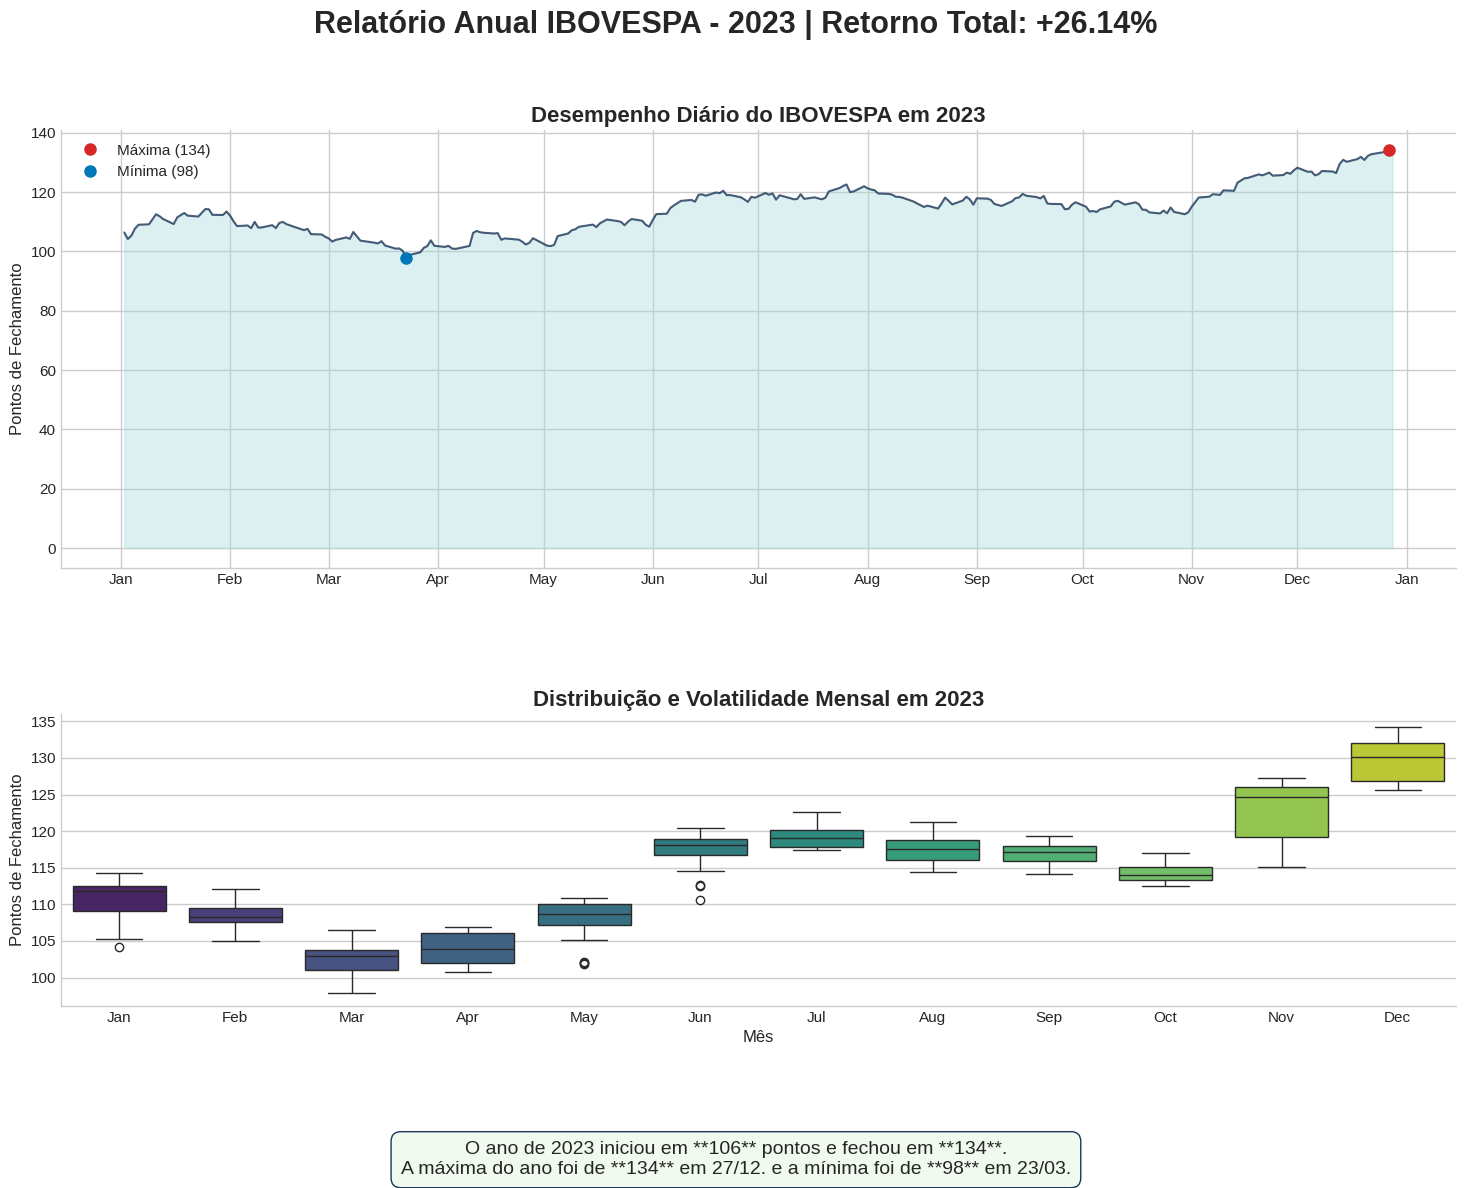

In [21]:
def analisar_ano_especifico(df, ano):

    df_ano = df[df.index.year == ano].copy()
    if df_ano.empty:
        print(f"AVISO: Nenhum dado encontrado para o ano {ano}.")
        return

    #Calcular estatísticas-chave para o resumo
    start_price = df_ano['Último'].iloc[0]
    end_price = df_ano['Último'].iloc[-1]
    annual_return = ((end_price / start_price) - 1) * 100
    high_price = df_ano['Último'].max()
    low_price = df_ano['Último'].min()
    date_high = df_ano['Último'].idxmax()
    date_low = df_ano['Último'].idxmin()

    # Configuração do Estilo e Figura
    plt.style.use('seaborn-v0_8-whitegrid')
    # Usamos GridSpec para dar mais altura ao gráfico principal
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 1, height_ratios=(3, 2))
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])

    # Gráfico Principal (Linha) com Destaques
    ax1.plot(df_ano.index, df_ano['Último'], color='#1d3557', linewidth=1.5, alpha=0.8)
    # Área preenchida sob a linha
    ax1.fill_between(df_ano.index, df_ano['Último'], color='#a8dadc', alpha=0.4)

    # Destaca os pontos de máxima e mínima
    ax1.plot(date_high, high_price, 'o', color='#d62828', markersize=8, label=f'Máxima ({high_price:,.0f})')
    ax1.plot(date_low, low_price, 'o', color='#0077b6', markersize=8, label=f'Mínima ({low_price:,.0f})')

    ax1.set_title(f'Desempenho Diário do IBOVESPA em {ano}', fontsize=16, weight='bold')
    ax1.set_ylabel('Pontos de Fechamento', fontsize=12)
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax1.legend()

    # Gráfico Secundário (Boxplots Mensais)
    # Substitui o regplot para mostrar a volatilidade de cada mês
    df_ano['Mes_nome'] = df_ano.index.strftime('%b')
    meses_ordenados = pd.to_datetime(df_ano.index.month.unique(), format='%m').strftime('%b')

    sns.boxplot(x='Mes_nome', y='Último', data=df_ano, ax=ax2, palette='viridis', order=meses_ordenados)
    ax2.set_title(f'Distribuição e Volatilidade Mensal em {ano}', fontsize=16, weight='bold')
    ax2.set_xlabel('Mês', fontsize=12)
    ax2.set_ylabel('Pontos de Fechamento', fontsize=12)

    # Título e Resumo Estatístico Dinâmico
    retorno_sinal = '+' if annual_return >= 0 else ''
    fig.suptitle(f'Relatório Anual IBOVESPA - {ano} | Retorno Total: {retorno_sinal}{annual_return:.2f}%',
                 fontsize=22, weight='bold', y=0.98)

    resumo_texto = (f'O ano de {ano} iniciou em **{start_price:,.0f}** pontos e fechou em **{end_price:,.0f}**.\n'
                    f'A máxima do ano foi de **{high_price:,.0f}** em {date_high.strftime("%d/%m")}, '
                    f'e a mínima foi de **{low_price:,.0f}** em {date_low.strftime("%d/%m")}.')

    # Adiciona um texto conclusivo diretamente na figura
    fig.text(0.5, 0.01, resumo_texto.replace(',', '.'), ha='center', fontsize=14,
             bbox=dict(boxstyle='round,pad=0.5', fc='#f1faee', ec='#1d3557', lw=1))

    # --- Acabamento ---
    for ax in [ax1, ax2]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.subplots_adjust(hspace=0.4, bottom=0.15)
    plt.show()


analisar_ano_especifico(df, ano=2023)

> Estes gráficos focam exclusivamente no comportamento do IBOVESPA durante o ano de 2023.

###  **Um Ano de Duas Metades**
* **Observação:** O primeiro semestre foi de volatilidade e movimento lateral. O segundo semestre, especialmente o último trimestre (Out-Dez), foi de uma **forte e consistente tendência de alta**.
* **O que isso significa:** Fatores macroeconômicos distintos influenciaram o mercado em cada metade do ano, culminando em um forte **"rally" de fim de ano**.

###  **Tendência Linear Positiva no Ano**
* **Observação:** O gráfico de regressão (inferior) mostra uma linha de tendência com uma inclinação claramente positiva.
* **O que isso significa:** Apesar das oscilações, na média, **o IBOVESPA subiu consistentemente ao longo dos meses de 2023**, confirmando que o ano, como um todo, foi de alta para o índice.